# Module 9 (Advanced) — Huấn luyện mô hình dự báo công suất (power curve)

**Bài toán hồi quy:** dự đoán công suất thực `cong_suat_kw` từ đặc trưng khí tượng `toc_do_gio`, `huong_gio`.

**Dùng để làm gì:**
- Biết dự báo tốc độ gió → ước lượng công suất/sản lượng tương lai.
- So sánh công suất **thực tế vs dự đoán** → phát hiện tua bin chạy dưới mức (bất thường).

Notebook này gọi các **hàm dùng chung** trong `mo_hinh_du_bao.py` (cùng dùng cho API và unit test), huấn luyện, đánh giá trên tập giữ lại (held-out), rồi **lưu model ra file `.joblib`** để chạy offline.

## Bước 1 — Đọc dữ liệu sạch

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Import core logic (hàm dùng chung cho notebook / API / test)
import mo_hinh_du_bao as mh

# Đọc dữ liệu sạch (đầu ra của Module 2)
df = mh.doc_du_lieu_sach()
print(f"Đã đọc {len(df):,} dòng. Các cột: {list(df.columns)}")
print(f"Đặc trưng dùng làm đầu vào: {mh.COT_DAC_TRUNG}")
print(f"Mục tiêu cần dự đoán     : {mh.COT_MUC_TIEU}")
df.head()

Đã đọc 48,835 dòng. Các cột: ['cong_suat_kw', 'toc_do_gio', 'cong_suat_ly_thuyet', 'huong_gio']
Đặc trưng dùng làm đầu vào: ['toc_do_gio', 'huong_gio']
Mục tiêu cần dự đoán     : cong_suat_kw


,cong_suat_kw,toc_do_gio,cong_suat_ly_thuyet,huong_gio
thoi_gian,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
2018-01-01 00:30:00,419.645904,5.659674,516.127569,271.258087
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


## Bước 2 — Huấn luyện mô hình và đánh giá

Dùng `RandomForestRegressor`. Dữ liệu chia 80% huấn luyện / 20% kiểm tra; các chỉ số bên dưới tính trên **tập kiểm tra** (dữ liệu model chưa từng thấy).

In [2]:
ket_qua = mh.huan_luyen(df)
model = ket_qua["model"]
metrics = ket_qua["metrics"]

print("Kết quả đánh giá trên tập kiểm tra:")
print(f"  - R²   (càng gần 1 càng tốt): {metrics['r2']}")
print(f"  - MAE  (sai số tuyệt đối TB): {metrics['mae']} kW")
print(f"  - RMSE (sai số quân phương) : {metrics['rmse']} kW")
print(f"  - Số dòng huấn luyện / kiểm tra: {metrics['n_train']:,} / {metrics['n_test']:,}")

Kết quả đánh giá trên tập kiểm tra:
  - R²   (càng gần 1 càng tốt): 0.9067
  - MAE  (sai số tuyệt đối TB): 163.72 kW
  - RMSE (sai số quân phương) : 385.35 kW
  - Số dòng huấn luyện / kiểm tra: 39,068 / 9,767


## Bước 3 — Trực quan: đường cong công suất do mô hình học được

So sánh điểm dữ liệu thực tế (xám) với công suất **dự đoán** theo tốc độ gió (đường đỏ), tại một hướng gió cố định.

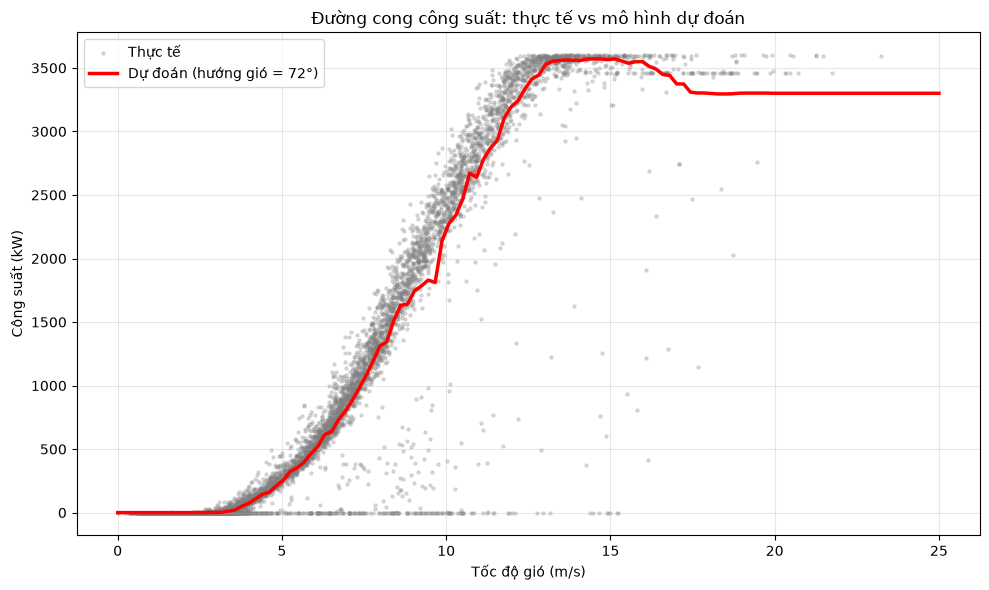

In [3]:
import numpy as np

# Quét dải tốc độ gió 0..25 m/s, cố định hướng gió = trung vị để vẽ đường cong
huong_co_dinh = float(df["huong_gio"].median())
luoi = pd.DataFrame({
    "toc_do_gio": np.linspace(0, 25, 120),
    "huong_gio": huong_co_dinh,
})
cong_suat_du_doan = mh.du_bao(model, luoi)

fig, ax = plt.subplots(figsize=(10, 6))
# Lấy mẫu điểm thực tế cho nhẹ
mau = df.sample(n=min(6000, len(df)), random_state=42)
ax.scatter(mau["toc_do_gio"], mau["cong_suat_kw"], s=5, alpha=0.25,
           color="gray", label="Thực tế")
ax.plot(luoi["toc_do_gio"], cong_suat_du_doan, color="red", linewidth=2.5,
        label=f"Dự đoán (hướng gió = {huong_co_dinh:.0f}°)")
ax.set_title("Đường cong công suất: thực tế vs mô hình dự đoán")
ax.set_xlabel("Tốc độ gió (m/s)")
ax.set_ylabel("Công suất (kW)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Bước 4 — Lưu mô hình ra file `.joblib`

Lưu kèm metadata (danh sách đặc trưng, mục tiêu, chỉ số) để API và test nạp lại dùng offline.

In [4]:
duong_dan = mh.luu_model(model, metrics)
print(f"Đã lưu model tại: {duong_dan}")

# Kiểm chứng: nạp lại và xem metadata
goi = mh.nap_model()
print("Metadata trong file model:")
print(f"  - Đặc trưng : {goi['cot_dac_trung']}")
print(f"  - Mục tiêu  : {goi['cot_muc_tieu']}")
print(f"  - Chỉ số    : {goi['metrics']}")

Đã lưu model tại: /home/testuser/Projects/Education/Final/Advanced/model/power_curve_model.joblib
Metadata trong file model:
  - Đặc trưng : ['toc_do_gio', 'huong_gio']
  - Mục tiêu  : cong_suat_kw
  - Chỉ số    : {'r2': 0.9067, 'mae': 163.72, 'rmse': 385.35, 'n_train': 39068, 'n_test': 9767}


## Bước 5 — Thử dự báo trên vài kịch bản tốc độ gió

Đây chính là cơ chế API `/api/du-bao` sẽ dùng: đưa đặc trưng vào → nhận công suất dự đoán.

In [5]:
kich_ban = pd.DataFrame({
    "toc_do_gio": [3.0, 5.0, 8.0, 12.0, 18.0, 25.0],
    "huong_gio": [180, 180, 180, 180, 180, 180],
})
kich_ban["cong_suat_du_doan_kw"] = mh.du_bao(goi["model"], kich_ban).round(1)
print("Dự báo công suất theo tốc độ gió (hướng gió = 180°):")
kich_ban

Dự báo công suất theo tốc độ gió (hướng gió = 180°):


,toc_do_gio,huong_gio,cong_suat_du_doan_kw
0,3.0,180,6.3
1,5.0,180,277.3
2,8.0,180,1388.4
3,12.0,180,3311.5
4,18.0,180,3468.4
5,25.0,180,3474.5
